# Does late money win?

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Propertyscout001/puntersedge-datasets/blob/main/notebooks/03_does_late_money_win.ipynb)

A runner that **firms** (its price shortens) in the last hour is said to carry "the money". A **drifter** goes the other way. Two questions:

1. Do runners that firm win more often than their **opening** price said they would?
2. Do they win more often than their **closing** price says?

If the answer to the first is yes and the second is no, the closing market has already absorbed whatever the late money knew. This notebook checks both on a month of Australian racing from the free [closing-line dataset](https://puntersedge.online/datasets), in Colab with nothing to install.

In [1]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RELEASE = "2026-09"
URL = ("https://puntersedge.online/datasets/au-racing-closing-lines/"
       f"{RELEASE}/au-racing-closing-lines-{RELEASE}.parquet")

# Reads the release straight from puntersedge.online (about 3 MB).
# Set PUNTERSEDGE_DATASET_FILE to the path of a downloaded copy to read that instead.
df = pd.read_parquet(os.environ.get("PUNTERSEDGE_DATASET_FILE", URL))

NAMES = {"tab": "TAB", "ladbrokes_au": "Ladbrokes", "pointsbetau": "PointsBet",
         "betright": "BetRight", "tabtouch": "TABtouch"}
print(f"{len(df):,} rows, {df.race_id.nunique():,} races, "
      f"{df.meeting_date_aet.min()} to {df.meeting_date_aet.max()}")
print("Bookmakers:", ", ".join(NAMES.get(b, b) for b in sorted(df.bookmaker_key.unique())))

233,872 rows, 6,274 races, 2026-09-01 to 2026-09-30
Bookmakers: BetRight, Ladbrokes, PointsBet, TAB, TABtouch


In [2]:
GREEN, AMBER, GREY, INK = "#1B7A4B", "#E3A008", "#8A948C", "#131C16"
plt.rcParams.update({
    "figure.dpi": 110, "font.size": 10, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.spines.top": False, "axes.spines.right": False, "axes.edgecolor": "#B8C1B6",
    "axes.grid": True, "grid.color": "#E6EAE3", "grid.linewidth": 0.8, "axes.axisbelow": True,
    "text.color": INK, "axes.labelcolor": INK, "xtick.color": "#5C6961", "ytick.color": "#5C6961",
    "text.parse_math": False,                 # "$3.00 to $6.99" is a price range, not maths
})

We use the market's margin-free consensus price for each runner: `consensus_open_price` from series that began 60 minutes before the jump, and `consensus_close_price` at the close. Races with a final result and one winner only.

In [3]:
# One row per runner, for races with a final result and exactly one winner.
# Harness results name the placegetters only, so an empty finish_position in a resulted
# race means the runner did not win.
winners = df[df.finish_position.eq(1)].groupby("race_id").runner_key.nunique()
resulted = df[df.result_status.eq("final")].race_id.unique()
single = winners[winners.eq(1)].index.intersection(resulted)

runners = (df[df.race_id.isin(single)]
           .groupby(["race_id", "runner_key"])
           .agg(category=("category", "first"),
                best_open=("open_win_price", "max"),
                best_close=("close_win_price", "max"),
                fair_open=("consensus_open_price", "first"),
                fair_close=("consensus_close_price", "first"),
                from_baseline=("open_is_baseline", "all"),
                won=("finish_position", lambda s: bool((s == 1).any())))
           .reset_index())
print(f"{runners.race_id.nunique():,} races with one winner, {len(runners):,} runners")

6,169 races with one winner, 48,947 runners


## Is the closing price right?

First, a check on the yardstick. Group runners by the probability the closing price gave them and compare it with how often they actually won. A well-calibrated market sits on the diagonal.

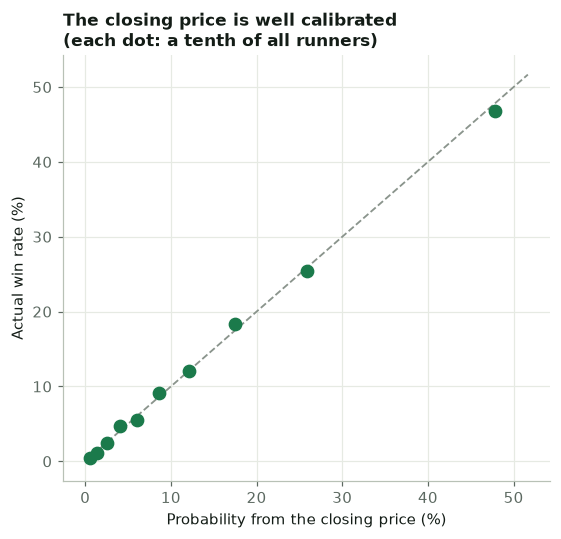

,runners,implied,won
bin,,,
"(-0.0009472, 0.00916]",4883,0.6,0.5
"(0.00916, 0.0187]",4882,1.4,1.2
"(0.0187, 0.0322]",4882,2.5,2.4
"(0.0322, 0.0493]",4882,4.0,4.7
"(0.0493, 0.0721]",4883,6.0,5.6
"(0.0721, 0.1]",4883,8.6,9.2
"(0.1, 0.145]",4881,12.2,12.0
"(0.145, 0.209]",4882,17.4,18.4
"(0.209, 0.32]",4884,25.8,25.5


In [4]:
cal = runners[runners.fair_close.notna()].assign(p=lambda x: 1 / x.fair_close)
cal["bin"] = pd.qcut(cal.p, 10)
c = cal.groupby("bin", observed=True).agg(runners=("won", "size"), implied=("p", "mean"), won=("won", "mean"))
c[["implied", "won"]] *= 100

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.plot([0, c.implied.max() * 1.08], [0, c.implied.max() * 1.08], ls="--", lw=1.2, color=GREY)
ax.plot(c.implied, c.won, "o", ms=8, color=GREEN)
ax.set_xlabel("Probability from the closing price (%)")
ax.set_ylabel("Actual win rate (%)")
ax.set_title("The closing price is well calibrated\n(each dot: a tenth of all runners)", loc="left")
fig.tight_layout()
plt.show()
c.round(1)

## Late money

Now group runners by how far the consensus price moved between 60 minutes out and the jump, and compare the actual win rate with what the opening price and the closing price implied.

In [5]:
mv = runners[runners.fair_open.notna() & runners.fair_close.notna()].copy()
mv["move"] = mv.fair_close / mv.fair_open - 1
labels = ["Firmed 30%+", "Firmed 15–30%", "Firmed 5–15%", "Steady", "Drifted 5–20%", "Drifted 20–50%", "Drifted 50%+"]
mv["group"] = pd.cut(mv.move, [-1, -0.3, -0.15, -0.05, 0.05, 0.2, 0.5, np.inf], labels=labels)
late = mv.groupby("group", observed=True).agg(runners=("won", "size"),
                                              opening_implied=("fair_open", lambda s: (1 / s).mean()),
                                              closing_implied=("fair_close", lambda s: (1 / s).mean()),
                                              won=("won", "mean"))
late[["opening_implied", "closing_implied", "won"]] *= 100
late.round(1)

,runners,opening_implied,closing_implied,won
group,,,,
Firmed 30%+,7184,3.8,6.5,6.5
Firmed 15–30%,7594,10.9,13.8,14.0
Firmed 5–15%,7204,17.9,19.8,19.4
Steady,6892,18.9,18.9,19.2
Drifted 5–20%,7446,16.2,14.5,14.5
Drifted 20–50%,6791,11.7,8.9,8.7
Drifted 50%+,5639,7.4,4.0,4.1


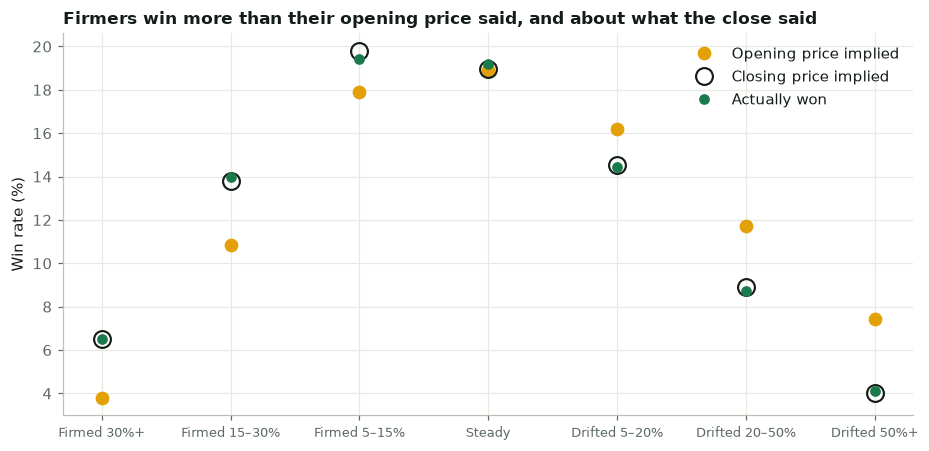

In [6]:
fig, ax = plt.subplots(figsize=(8.6, 4.2))
x = np.arange(len(late))
ax.plot(x, late.opening_implied, "o", ms=8, color=AMBER, label="Opening price implied")
ax.plot(x, late.closing_implied, "o", ms=11, mfc="none", mec=INK, mew=1.4, label="Closing price implied")
ax.plot(x, late.won, "o", ms=6, color=GREEN, label="Actually won")
ax.set_xticks(x, late.index, rotation=0, fontsize=8.5)
ax.set_ylabel("Win rate (%)")
ax.set_title("Firmers win more than their opening price said, and about what the close said", loc="left")
ax.legend(frameon=False, loc="upper right")
fig.tight_layout()
plt.show()

In [7]:
f = late.loc["Firmed 30%+"]
print(f"Runners that firmed 30% or more won {f.won:.1f}% of the time: their opening price implied "
      f"{f.opening_implied:.1f}% and their closing price {f.closing_implied:.1f}%.")
d = late.loc["Drifted 50%+"]
print(f"Runners that drifted 50% or more won {d.won:.1f}%: opening price {d.opening_implied:.1f}%, "
      f"closing price {d.closing_implied:.1f}%.")

Runners that firmed 30% or more won 6.5% of the time: their opening price implied 3.8% and their closing price 6.5%.
Runners that drifted 50% or more won 4.1%: opening price 7.4%, closing price 4.0%.


The late money was right about which runners would improve their chances, and the closing price already knew it. Backing a runner *because* it has firmed buys a price that has already moved.

## What being early is worth

The flip side: if you can get on **before** the move, at the best price available 60 minutes out, the return is very different from backing the same runners at the best closing price. This is hindsight (nobody knows in advance which runners will firm), but it shows where the value in a price move sits.

In [8]:
mv["ret_open"] = np.where(mv.won, mv.best_open - 1, -1.0)
mv["ret_close"] = np.where(mv.won, mv.best_close - 1, -1.0)
worth = mv.groupby("group", observed=True)[["ret_open", "ret_close"]].mean() * 100
worth.columns = ["Return at best opening price (%)", "Return at best closing price (%)"]
worth.round(1)

,Return at best opening price (%),Return at best closing price (%)
group,,
Firmed 30%+,-2.5,-29.1
Firmed 15–30%,-8.5,-17.7
Firmed 5–15%,-18.6,-17.7
Steady,-23.7,-16.7
Drifted 5–20%,-35.7,-21.8
Drifted 20–50%,-52.5,-33.3
Drifted 50%+,-66.2,-35.0


## By code

In [9]:
firmers = mv[mv.move <= -0.15]
(firmers.groupby("category")
        .agg(runners=("won", "size"),
             opening_implied=("fair_open", lambda s: (1 / s).mean() * 100),
             closing_implied=("fair_close", lambda s: (1 / s).mean() * 100),
             won=("won", lambda s: s.mean() * 100))
        .round(1))

,runners,opening_implied,closing_implied,won
category,,,,
greyhound,7745,7.8,10.7,11.6
harness,3459,6.9,9.6,8.7
horse,3574,7.1,9.8,9.3


## What this shows

- The closing price is a good estimate of a runner's chance, which is why [closing-line value](02_measure_your_closing_line_value.ipynb) works as a scorecard.
- Runners that firm in the last hour win far more often than their opening price implied and about as often as their closing price implies. The information arrives before the jump and the market prices it.
- The value in a move belongs to whoever bet before it. Following the move at the close gains nothing over the close itself.

Previous: [Measure your closing-line value](02_measure_your_closing_line_value.ipynb) · [Which bookmaker is sharpest?](01_which_bookmaker_is_sharpest.ipynb)

---
Data: [PuntersEdge Australian racing closing-line sample](https://puntersedge.online/datasets), CC BY 4.0.
Credit "PuntersEdge Australian racing closing-line sample (puntersedge.online)". Code in this notebook: MIT.
The full archive, every served bookmaker and New Zealand racing are in the [PuntersEdge API](https://puntersedge.online/api).

For research and analysis, not betting advice. 18+. Gambling Help Online: 1800 858 858.